# 01 · Corpus construction

**Authorship Attribution and Style Fingerprinting in Bangla Literature**
KUET CSE 4122 — NLP Laboratory

This notebook turns Bengali Wikisource into a balanced, work-labelled,
passage-level corpus, and documents every decision that shaped it. The
proposal commits to treating corpus construction as *part of the methodology,
not a black box*, so the filtering statistics are reported rather than assumed.

Three things decide the quality of everything downstream:

1. **Proofreading filter.** Wikisource marks each scanned page with a quality
   level. Level 1 is raw OCR, and for Bangla that OCR is frequently garbled
   into Devanagari look-alikes. Only pages at level ≥ 3 (community-proofread)
   are admitted.
2. **Bangla-ratio filter.** Lines whose characters are less than 88 % in the
   Bangla Unicode block are dropped — this removes running headers, English
   epigraphs, page numbers and the residue of bad OCR in one rule.
3. **Work labelling.** Every passage records the book it came from, because
   the train/test split in notebook 02 is made over *works*, not passages.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Bengali glyphs need a font that has them; fall back silently if absent.
for _f in ("Nirmala UI", "Vrinda", "Shonar Bangla", "Noto Sans Bengali"):
    try:
        matplotlib.font_manager.findfont(_f, fallback_to_default=False)
        plt.rcParams["font.family"] = _f
        break
    except Exception:
        continue
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.25})
pd.set_option("display.width", 160, "display.max_columns", 60)

from banglastylo import config
print("project root:", ROOT)

project root: E:\NLP Project\Bangla-author-fingerprinting


## 1.1 Run the crawl

`build_raw_corpus` is cached on disk: if `data/raw/corpus_raw.json` already
exists from `scripts/01_build_corpus.py`, this cell just loads it.

In [2]:
from banglastylo import corpus

raw_path = config.RAW / "corpus_raw.json"
if raw_path.exists():
    raw = json.loads(raw_path.read_text(encoding="utf-8"))
    print("loaded cached crawl")
else:
    raw = corpus.build_raw_corpus()

summary = pd.DataFrame([
    {"author": a,
     "works": len(w),
     "characters": sum(len(t) for t in w.values())}
    for a, w in raw.items()
]).sort_values("characters", ascending=False)
summary["author_en"] = summary["author"].map(lambda k: config.AUTHORS[k]["en"])
summary

loaded cached crawl


,author,works,characters,author_en
5,abanindranath,5,1314952,Abanindranath Tagore
2,sarat,5,1201122,Sarat Chandra Chattopadhyay
0,tagore,14,1093105,Rabindranath Tagore
3,vidyasagar,12,929266,Ishwar Chandra Vidyasagar
1,bankim,6,916263,Bankim Chandra Chattopadhyay
4,haraprasad,3,444843,Haraprasad Shastri
6,vivekananda,6,255265,Swami Vivekananda
7,pramatha,1,51114,Pramatha Chaudhuri


## 1.2 What the proofreading filter cost

`provenance.json` records, for every scanned book, how many pages existed and
how many survived the quality filter. This is the number to quote when
someone asks how much of Wikisource is actually usable.

In [3]:
prov_path = config.RAW / "provenance.json"
prov = json.loads(prov_path.read_text(encoding="utf-8")) if prov_path.exists() else {}

rows = [dict(author=a, **r) for a, rs in prov.items() for r in rs]
prov_df = pd.DataFrame(rows)
if len(prov_df):
    prov_df["kept_frac"] = prov_df["n_proofread"] / prov_df["n_pages"].clip(lower=1)
    print(f"{len(prov_df)} scanned books touched; "
          f"{prov_df['n_pages'].sum():,} scan pages seen, "
          f"{prov_df['n_proofread'].sum():,} proofread "
          f"({prov_df['n_proofread'].sum() / max(prov_df['n_pages'].sum(),1):.1%})")
    display(prov_df.groupby("author")[["n_pages", "n_proofread", "n_chars"]]
            .sum().sort_values("n_chars", ascending=False))

57 scanned books touched; 7,480 scan pages seen, 7,158 proofread (95.7%)


,n_pages,n_proofread,n_chars
author,,,
abanindranath,975,933,1314952
sarat,730,725,1201122
tagore,2384,2295,1093105
vidyasagar,1178,1103,929266
bankim,1063,1029,916263
haraprasad,491,474,444843
vivekananda,538,483,255265
pramatha,121,116,51114


## 1.3 Segment into passages

A **passage** is ~220 tokens cut on sentence boundaries — long enough for
sentence-length statistics to mean something, short enough to give a few
hundred independent samples per author.

Near-duplicate passages are removed with an 8-gram shingle overlap test.
This matters more than it looks: Wikisource hosts several editions of the same
novel, and without this filter the "same" text would appear on both sides of a
split.

In [4]:
passages = corpus.build_passages(raw)
print(f"\n{len(passages):,} passages before balancing")

df = pd.DataFrame([p.__dict__ for p in passages])
display(df.groupby("author").agg(
    passages=("passage_id", "count"),
    works=("work", "nunique"),
    mean_tokens=("n_tokens", "mean"),
    mean_sentences=("n_sentences", "mean"),
).sort_values("passages", ascending=False))

[tagore]   691 passages from 14 works


[bankim]   607 passages from 6 works


[sarat]   855 passages from 5 works


[vidyasagar]   591 passages from 12 works
[haraprasad]    49 passages from 1 works


[abanindranath]   938 passages from 5 works
[vivekananda]   160 passages from 6 works
[pramatha]    38 passages from 1 works

3,929 passages before balancing


,passages,works,mean_tokens,mean_sentences
author,,,,
abanindranath,938,5,234.087420,13.976546
sarat,855,5,228.645614,17.904094
tagore,691,14,233.044863,15.835022
bankim,607,6,229.683690,19.871499
vidyasagar,591,12,229.912014,15.142132
vivekananda,160,6,233.625000,13.756250
haraprasad,49,1,226.755102,18.285714
pramatha,38,1,228.473684,19.447368


## 1.4 Balance

An author is dropped from the study for too few passages *or* too few distinct
works. The second criterion is the binding one: a one-book author cannot take
part in a work-disjoint split at all, because every passage of theirs would
land in the same split. Who was dropped is printed rather than glossed over.

The survivors are down-sampled to the smallest of them, walking each author's
works round-robin so that balancing does not silently reduce an author to a
single book.

In [5]:
balanced, dropped = corpus.balance(passages)
corpus.save_passages(balanced)
if dropped:
    pd.DataFrame(dropped).to_csv(config.TABLES / "dropped_authors.csv", index=False)
    display(pd.DataFrame(dropped).assign(
        author_en=lambda d: d["author"].map(lambda k: config.AUTHORS[k]["en"])))

bdf = pd.DataFrame([p.__dict__ for p in balanced])
n_authors = bdf['author'].nunique()
print(f"\n{len(balanced):,} passages, {n_authors} authors, "
      f"chance accuracy = {1/n_authors:.3f}")
display(bdf.groupby("author").agg(
    passages=("passage_id", "count"),
    works=("work", "nunique"),
    tokens=("n_tokens", "sum"),
))

  dropping haraprasad: 49 passages < 300; 1 works < 3
  dropping pramatha: 38 passages < 300; 1 works < 3
  dropping vivekananda: 160 passages < 300
  abanindranath: 591 passages from 5 works
  bankim: 591 passages from 6 works
  sarat: 591 passages from 5 works
  tagore: 591 passages from 14 works
  vidyasagar: 591 passages from 12 works


wrote E:\NLP Project\Bangla-author-fingerprinting\data\processed\passages.jsonl (2955 passages)


,author,passages,works,reason,author_en
0,haraprasad,49,1,49 passages < 300; 1 works < 3,Haraprasad Shastri
1,pramatha,38,1,38 passages < 300; 1 works < 3,Pramatha Chaudhuri
2,vivekananda,160,6,160 passages < 300,Swami Vivekananda



2,955 passages, 5 authors, chance accuracy = 0.200


,passages,works,tokens
author,,,
abanindranath,591,5,137628
bankim,591,6,135807
sarat,591,5,135197
tagore,591,14,138097
vidyasagar,591,12,135878


## 1.5 Corpus figures

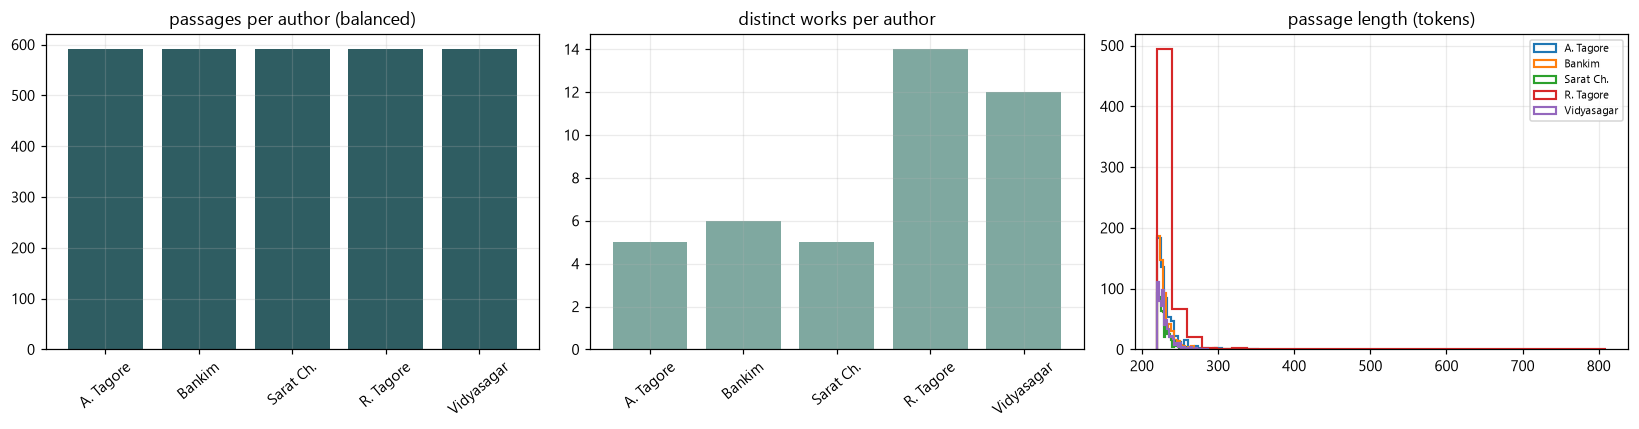

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

order = sorted(bdf["author"].unique())
names = [config.AUTHORS[a]["short"] for a in order]

axes[0].bar(names, [(bdf.author == a).sum() for a in order], color="#2F5D62")
axes[0].set_title("passages per author (balanced)")
axes[0].tick_params(axis="x", rotation=40)

axes[1].bar(names, [bdf.loc[bdf.author == a, "work"].nunique() for a in order],
            color="#7FA8A0")
axes[1].set_title("distinct works per author")
axes[1].tick_params(axis="x", rotation=40)

for a, n in zip(order, names):
    sub = bdf.loc[bdf.author == a, "n_tokens"]
    axes[2].hist(sub, bins=30, histtype="step", lw=1.4, label=n)
axes[2].set_title("passage length (tokens)")
axes[2].legend(fontsize=7)

fig.tight_layout()
fig.savefig(config.FIGURES / "corpus_overview.png", dpi=200)
fig.savefig(config.REPORT_FIGURES / "corpus_overview.png", dpi=200)
plt.show()

## 1.6 A sample passage from each author

In [7]:
for a in order:
    row = bdf[bdf.author == a].iloc[0]
    print("=" * 90)
    print(f"{config.AUTHORS[a]['en']}  ({config.AUTHORS[a]['bn']}, "
          f"{config.AUTHORS[a]['years']})")
    print(f"work: {row['work'][:80]}")
    print("-" * 90)
    print(row["text"][:380].replace("\n", " "), "…")
print("=" * 90)

Abanindranath Tagore  (অবনীন্দ্রনাথ ঠাকুর, 1871-1951)
work: আলোর ফুলকি :: আলোর ফুলকি.djvu
------------------------------------------------------------------------------------------
ব্যাঙের কড়া মুর থেকে আরম্ভ ক'রে ঝিঝির ঝিমে সুরটি পর্যন্ত সবই গান হয়ে এক তানে বাজছে যেন এই স্বপনপাখির মিষ্টি গলায়। কুঁকড়ো অবাক হয়ে বলে উঠলেন, "এ যে জগৎজোড়াগান, এর তো জুড়ি নেই। স্বপনপাখি কার কানে তুমি কী কথা বলে যাচ্ছ কে তা জানে।" অমনি কাঠবেরালি বললে, "আমনি শুনছি ছুটি হল, খেলা করো'।" খরগোস বললে, "আমি শুনছি শিশিরে-ভেজা সবুজ মাঠে চলো'" বনবেরাল বললে, "শুনছি চাদের আলো এল'" মাট …
Bankim Chandra Chattopadhyay  (বঙ্কিমচন্দ্র চট্টোপাধ্যায়, 1838-1894)
work: আনন্দমঠ (১৮৮৩) :: আনন্দমঠ (দ্বিতীয় সংস্করণ, ১৮৮৩).djvu
------------------------------------------------------------------------------------------
কিছুই বুঝিতে পারিতেছে না। এ সকল কথা ত অপরাধীর কথাবার্ত্তার মত নহে। কল্যাণীরও ভাব বিচিত্র। সেও ত অবিশ্বাসিনীর মত পলাইল না, ভীত হইল না, লজ্জিত নহে-কিছুই না বরং মৃদু মৃদু হাসিতেছে। আর কল্যাণী-যে সেই বৃক্ষতলে অনায়াসে

## 1.7 Corpus statistics table for the report

In [8]:
stats = bdf.groupby("author").agg(
    passages=("passage_id", "count"),
    works=("work", "nunique"),
    tokens=("n_tokens", "sum"),
    mean_passage_tokens=("n_tokens", "mean"),
)
stats["author"] = [config.AUTHORS[a]["en"] for a in stats.index]
stats["years"] = [config.AUTHORS[a]["years"] for a in stats.index]
stats = stats[["author", "years", "works", "passages", "tokens",
               "mean_passage_tokens"]]
stats.to_csv(config.TABLES / "corpus_stats.csv", index=False)

tex = [r"\begin{tabular}{llrrrr}", r"\toprule",
       r"Author & Period & Works & Passages & Tokens & Mean tokens/passage \\",
       r"\midrule"]
for _, r in stats.iterrows():
    tex.append(f"{r['author']} & {r['years']} & {r['works']} & {r['passages']} & "
               f"{r['tokens']:,} & {r['mean_passage_tokens']:.0f} \\\\")
tex += [r"\midrule",
        f"\\textbf{{Total}} & & {stats['works'].sum()} & {stats['passages'].sum()} & "
        f"{stats['tokens'].sum():,} & \\\\",
        r"\bottomrule", r"\end{tabular}"]
(config.TABLES / "corpus_stats.tex").write_text("\n".join(tex), encoding="utf-8")
stats

,author,years,works,passages,tokens,mean_passage_tokens
author,,,,,,
abanindranath,Abanindranath Tagore,1871-1951,5,591,137628,232.873096
bankim,Bankim Chandra Chattopadhyay,1838-1894,6,591,135807,229.791878
sarat,Sarat Chandra Chattopadhyay,1876-1938,5,591,135197,228.759729
tagore,Rabindranath Tagore,1861-1941,14,591,138097,233.666667
vidyasagar,Ishwar Chandra Vidyasagar,1820-1891,12,591,135878,229.912014
